Cargando datos...
Train: 33452 filas | Test: 8363 filas

Plantando el Bosque Aleatorio... (Esto será rapidísimo)
✅ Entrenamiento completado.
Accuracy Train: 54.86%
Accuracy Test:  50.45%

--- INICIANDO BACKTEST ---
Horas en LONG:   1237
Horas en SHORT:  3003
Horas NEUTRALES: 4123


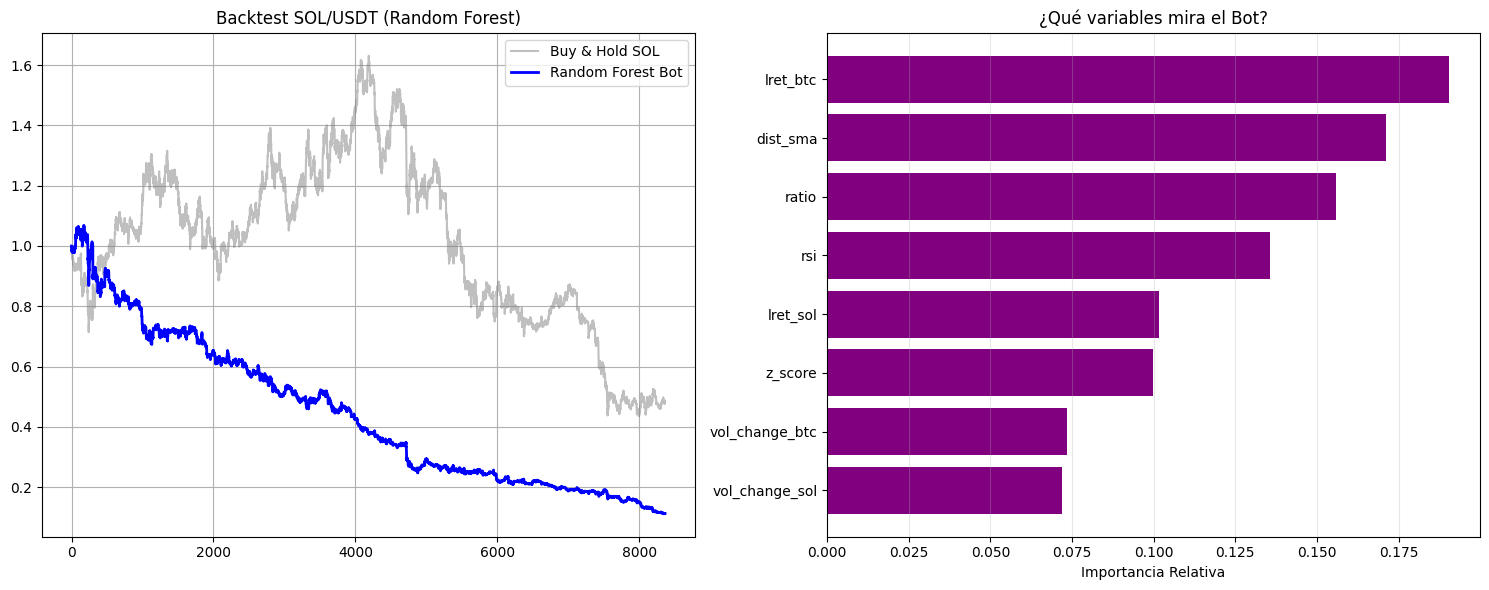


Retorno Bot: -88.75%
Retorno Mercado: -51.93%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# --- 1. CONFIGURACIÓN ---
FILE_NAME = 'datos_crypto_sol_btc_1h_historico.csv'
MODEL_NAME = 'modelo_rf_sol.pkl'

# --- 2. CARGA Y PREPARACIÓN DE DATOS ---
print("Cargando datos...")
df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)

# Las mismas features de antes
features =['lret_btc', 'lret_sol', 'vol_change_btc', 'vol_change_sol', 'ratio', 'z_score', 'rsi', 'dist_sma']
target = 'Target'

X = df[features].values
y = df[target].values

# Split Temporal Estricto (Sin trampas)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")

# --- 3. ENTRENAMIENTO (RANDOM FOREST) ---
# n_estimators: Número de árboles en el bosque (100 a 500 es ideal)
# max_depth: PROFUNDIDAD MÁXIMA. Clave para que no haga overfitting (le ponemos freno en 5 o 6)
print("\nPlantando el Bosque Aleatorio... (Esto será rapidísimo)")

rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5,        # <--- Freno anti-overfitting
    min_samples_split=50,
    random_state=42,
    n_jobs=-1           # Usa todos los núcleos de tu PC
)

# Entrenar
rf_model.fit(X_train, y_train)
print("✅ Entrenamiento completado.")

# Guardar modelo
joblib.dump(rf_model, MODEL_NAME)

# Evaluar precisión cruda
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Accuracy Train: {train_acc:.2%}")
print(f"Accuracy Test:  {test_acc:.2%}")

# --- 4. BACKTESTING ---
print("\n--- INICIANDO BACKTEST ---")
# En Random Forest, predict_proba devuelve dos columnas: [Prob_Bajar, Prob_Subir]
# Nos quedamos con la columna 1 (Prob_Subir)
predictions = rf_model.predict_proba(X_test)[:, 1]

market_returns = df['lret_sol'].values[split_idx:]

# Umbrales
# Los árboles suelen ser menos extremos en sus probabilidades. 
# Usaremos 0.52 y 0.48 para empezar.
UPPER, LOWER = 0.52, 0.48 
signals = np.zeros(len(predictions))
signals[predictions > UPPER] = 1
signals[predictions < LOWER] = -1

# Estadísticas de posiciones
print(f"Horas en LONG:   {np.sum(signals == 1)}")
print(f"Horas en SHORT:  {np.sum(signals == -1)}")
print(f"Horas NEUTRALES: {np.sum(signals == 0)}")

# Costes (0.05% comisión por lado en Binance, Borrow fee 10% anual)
COMMISSION = 0.0005 
BORROW_FEE = (0.10 / 365 / 24) 

equity =[1.0]
position = 0

for i in range(len(predictions)):
    current_ret = 0
    cost = 0
    
    if signals[i] != position: 
        cost = COMMISSION
    
    if position == 1: 
        current_ret = market_returns[i]
    elif position == -1: 
        current_ret = -market_returns[i] - BORROW_FEE
        
    equity.append(equity[-1] * (1 + current_ret - cost))
    position = signals[i]

# --- 5. VISUALIZACIÓN ---
plt.figure(figsize=(15, 6))

# Gráfico 1: Curva de Capital
plt.subplot(1, 2, 1)
plt.plot(np.cumprod(1 + market_returns), label='Buy & Hold SOL', color='gray', alpha=0.5)
plt.plot(equity, label='Random Forest Bot', color='blue', linewidth=2)
plt.title('Backtest SOL/USDT (Random Forest)')
plt.legend()
plt.grid(True)

# Gráfico 2: FEATURE IMPORTANCE (El superpoder de RF)
# Esto nos dirá a qué le está prestando atención el modelo
plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.title('¿Qué variables mira el Bot?')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRetorno Bot: {(equity[-1]-1)*100:.2f}%")
print(f"Retorno Mercado: {(np.cumprod(1 + market_returns)[-1]-1)*100:.2f}%")